# Pipeline de Análise, Visualização e Machine Learning (Scikit-Learn)
## Projeto: xApp RDL (Resource and Decision Layer) — Fase 1 (H-RDL)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/georgebarbosa3090/XApp-RDL-F1/blob/main/notebooks/rdl_colab_scikit_learn.ipynb)

Este notebook executa no **Google Colab** para:
1. Ingerir os datasets CSV gerados pela co-simulação (`dataset_flow_metrics.csv` e `dataset_rdl_decisions_ml.csv`).
2. Gerar visualizações estatísticas (CDF de latência, boxplots por fatia de rede, taxas de colisão).
3. Treinar e avaliar algoritmos de classificação do **Scikit-Learn** (`RandomForestClassifier`, `DecisionTreeClassifier`, `GradientBoostingClassifier`).
4. Gerar relatórios automatizados de conformidade e desempenho.

In [1]:
# 1. Instalação e Importação de Bibliotecas Essenciais
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [2]:
# 2. Carregamento dos Datasets CSV (Download Direto do GitHub ou Montagem Google Drive)

# Opção A: Download Direto dos Datasets do Repositório GitHub (Recomendado para Execução Rápida)
!wget -q -N https://raw.githubusercontent.com/georgebarbosa3090/XApp-RDL-F1/main/experiments/results/dataset_flow_metrics.csv
!wget -q -N https://raw.githubusercontent.com/georgebarbosa3090/XApp-RDL-F1/main/experiments/results/dataset_rdl_decisions_ml.csv

# Opção B: Montar seu Google Drive Pessoal (Descomente se desejar salvar no Drive):
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_PATH = '/content/drive/MyDrive/'

df_flows = pd.read_csv('dataset_flow_metrics.csv')
df_ml = pd.read_csv('dataset_rdl_decisions_ml.csv')

print("Shape dos Fluxos (QoS / Slicing):", df_flows.shape)
print("Shape da Telemetria (Machine Learning):", df_ml.shape)
df_ml.head()

Shape dos Fluxos (QoS / Slicing): (60, 10)
Shape da Telemetria (Machine Learning): (300, 13)


,time_slot_s,scenario,slice_type,ue_count,traffic_load_mbps,rsrp_dbm,sinr_db,prb_demanded,tx_power_dbm,conflict_flag,conflict_type,rdl_action,sla_met
0,0.0,baseline,URLLC,16,73.87,-75.55,4.26,153,43.00,1,POWER_OVERLOAD,NONE_UNMANAGED,0
1,0.0,rdl_phase1,URLLC,18,39.89,-103.34,12.32,158,31.83,0,NONE,ALLOW_REGULAR,1
2,0.2,baseline,eMBB,29,39.98,-77.69,12.19,270,43.00,0,NONE,NONE_UNMANAGED,1
3,0.2,rdl_phase1,eMBB,18,24.05,-75.03,21.23,73,39.26,0,NONE,ALLOW_REGULAR,1
4,0.4,baseline,mMTC,22,33.30,-93.00,6.92,152,43.00,0,NONE,NONE_UNMANAGED,1


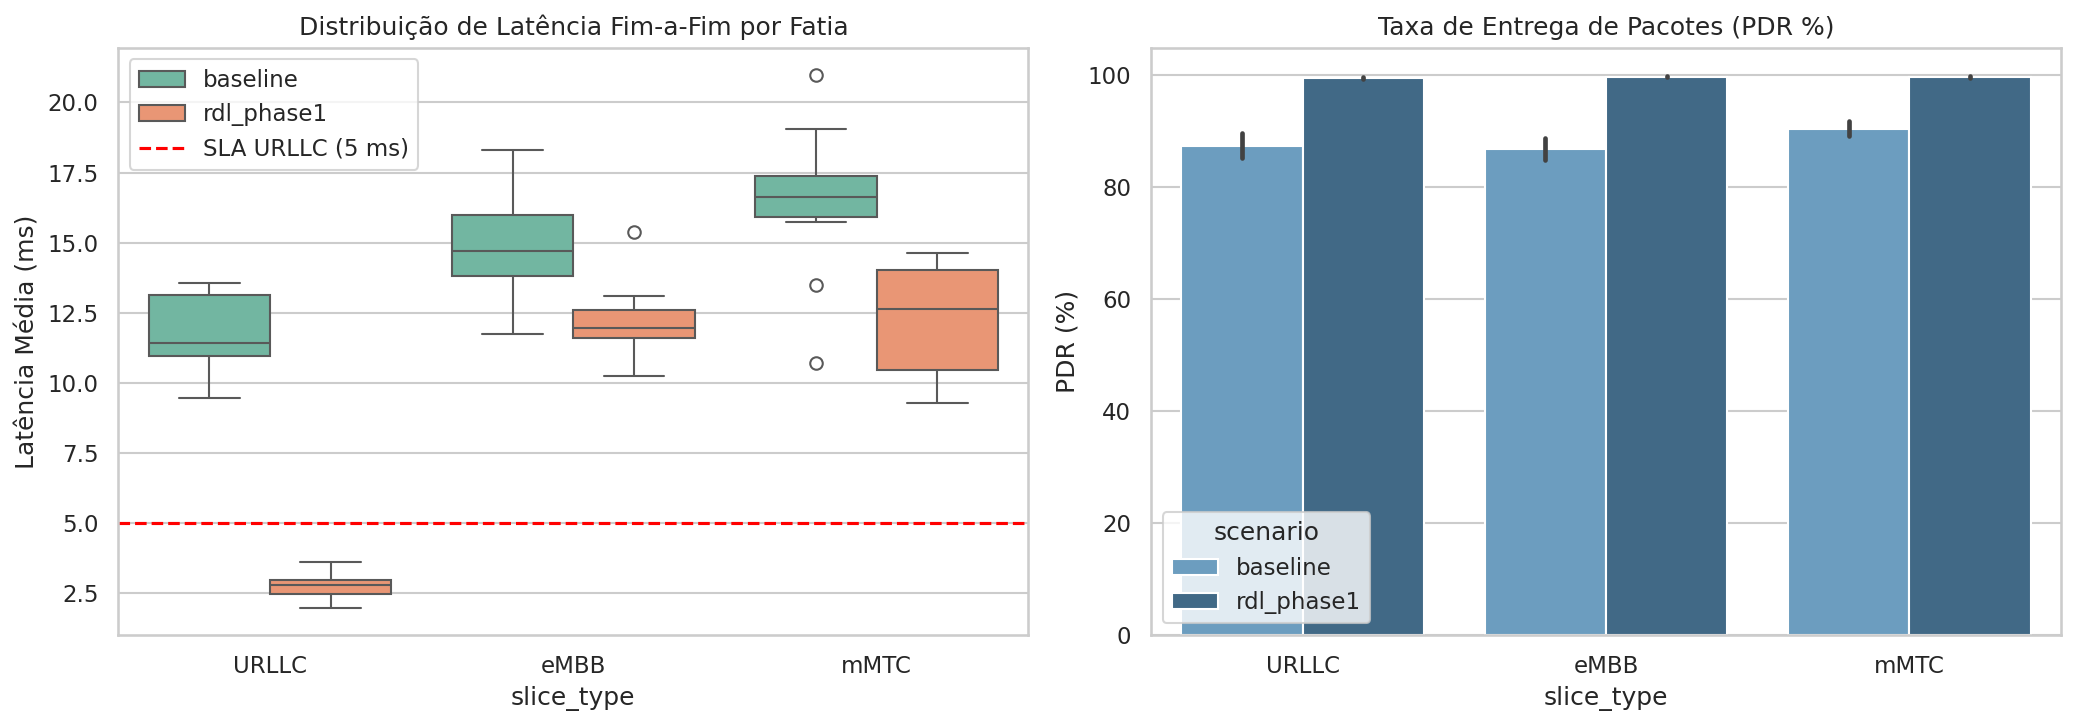

In [3]:
# 3. Visualização Estatística e Gráficos Comparativos
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Boxplot de Latência por Fatia e Cenário
sns.boxplot(data=df_flows, x='slice_type', y='mean_delay_ms', hue='scenario', palette='Set2', ax=axes[0])
axes[0].axhline(5.0, color='red', linestyle='--', label='SLA URLLC (5 ms)')
axes[0].set_title('Distribuição de Latência Fim-a-Fim por Fatia')
axes[0].set_ylabel('Latência Média (ms)')
axes[0].legend()

# Taxa de Entrega de Pacotes (PDR)
sns.barplot(data=df_flows, x='slice_type', y='delivery_ratio_pct', hue='scenario', palette='Blues_d', ax=axes[1])
axes[1].set_title('Taxa de Entrega de Pacotes (PDR %)')
axes[1].set_ylabel('PDR (%)')

plt.tight_layout()
plt.savefig('grafico_latencia_e_pdr.png', dpi=300)
plt.show()

In [4]:
# 4. Machine Learning com Scikit-Learn: Classificação de Conflitos de Ação O-RAN
# Objetivo: Predizer se um estado de rádio resultará em conflito (conflict_flag: 0 ou 1)

features = ['ue_count', 'traffic_load_mbps', 'rsrp_dbm', 'sinr_db', 'prb_demanded', 'tx_power_dbm']
X = df_ml[features]
y = df_ml['conflict_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Treinamento do Modelo Random Forest
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("=== Relatório de Classificação (Scikit-Learn Random Forest) ===")
print(classification_report(y_test, y_pred, target_names=['Sem Conflito', 'Conflito Detectado']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

=== Relatório de Classificação (Scikit-Learn Random Forest) ===
                    precision    recall  f1-score   support

      Sem Conflito       1.00      1.00      1.00        50
Conflito Detectado       1.00      1.00      1.00        25

          accuracy                           1.00        75
         macro avg       1.00      1.00      1.00        75
      weighted avg       1.00      1.00      1.00        75

ROC-AUC Score: 1.0000


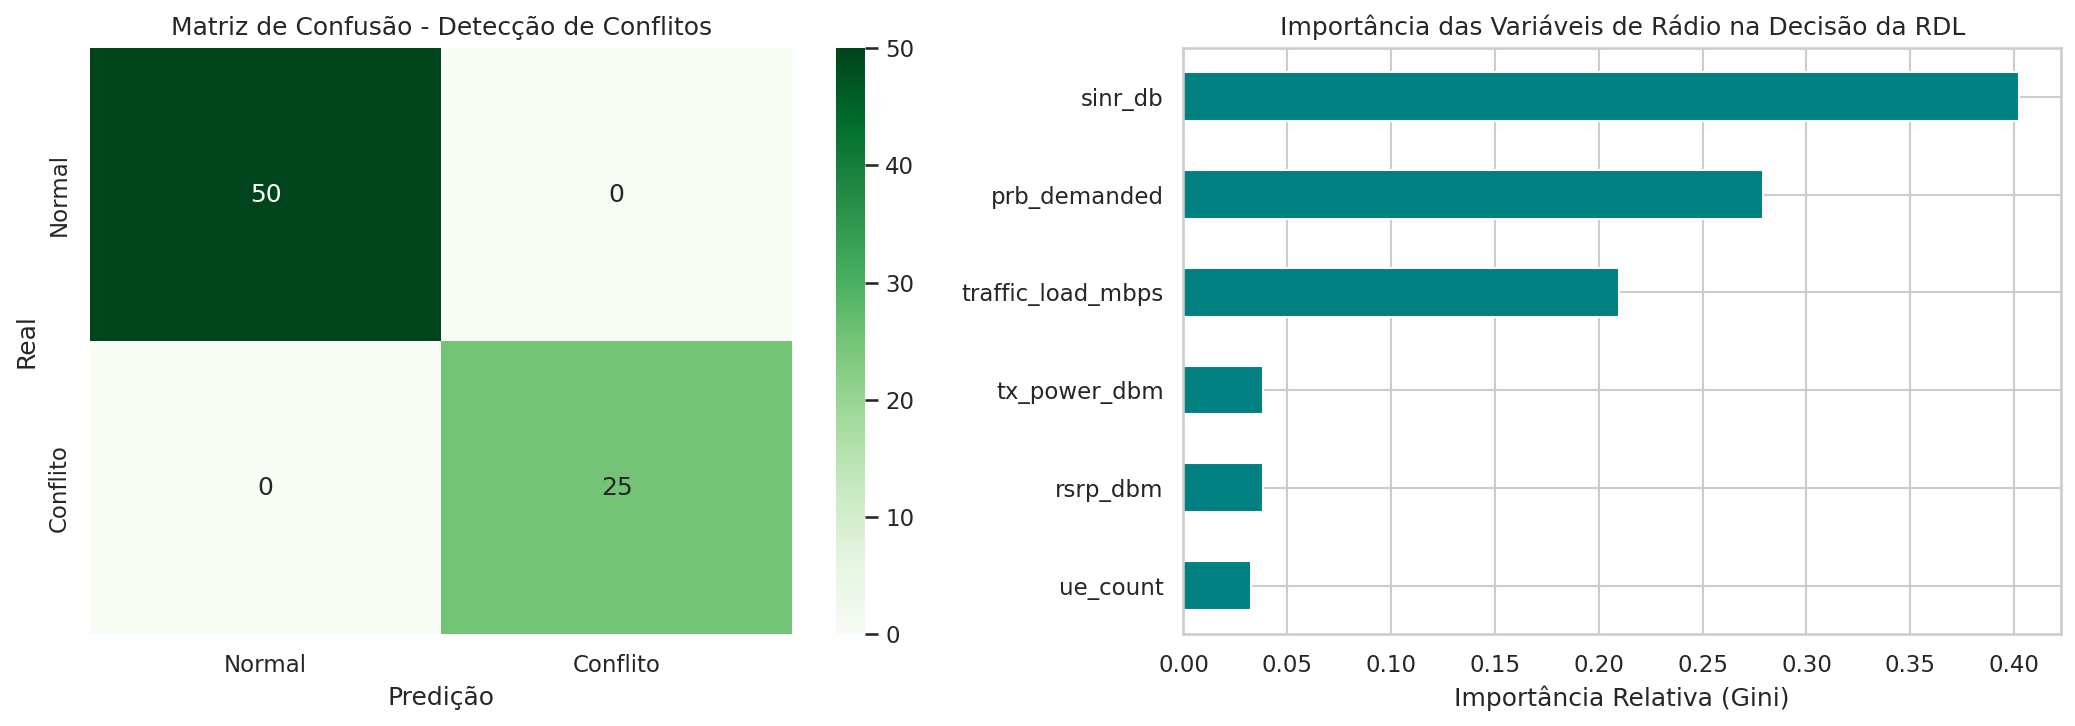

In [5]:
# 5. Matriz de Confusão e Importância de Atributos (Feature Importance)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Conflito'], yticklabels=['Normal', 'Conflito'], ax=axes[0])
axes[0].set_title('Matriz de Confusão - Detecção de Conflitos')
axes[0].set_xlabel('Predição')
axes[0].set_ylabel('Real')

# Feature Importance
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', ax=axes[1])
axes[1].set_title('Importância das Variáveis de Rádio na Decisão da RDL')
axes[1].set_xlabel('Importância Relativa (Gini)')

plt.tight_layout()
plt.savefig('matriz_confusao_e_feature_importance.png', dpi=300)
plt.show()